In [1]:
import pandas as pd
df=pd.read_excel('/home/elena/esercizi/food/ffpi-data-2026-05.xls',sheet_name='Indices_Monthly',skiprows=2)

In [8]:
xl = pd.ExcelFile('/home/elena/esercizi/food/ffpi-data-2026-05.xls')
print(xl.sheet_names)

['Indices_Monthly', 'Annual', 'Indices_Monthly_Real', 'Annual_Real']


In [2]:
df=df.dropna(axis=1,how='all')

In [3]:
df=df.drop(columns=['Unnamed: 36','Unnamed: 65'])

In [4]:
df=df.dropna(axis=0,how='all')

In [5]:
df.head()

,Date,Food Price Index,Meat,Dairy,Cereals,Oils,Sugar
1,1990-01-01,64.444201,74.272219,53.503031,64.140607,44.587672,87.877833
2,1990-02-01,64.728299,76.781027,52.218634,62.222377,44.500514,90.662693
3,1990-03-01,64.033021,78.543983,41.367123,61.259884,45.745434,95.056585
4,1990-04-01,66.015997,81.190035,48.427068,62.820731,44.017094,94.313956
5,1990-05-01,64.632844,81.756679,39.189651,61.982826,45.499631,90.353265


In [6]:
df.shape

(436, 7)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 436 entries, 1 to 436
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              436 non-null    datetime64[us]
 1   Food Price Index  436 non-null    float64       
 2   Meat              436 non-null    float64       
 3   Dairy             436 non-null    float64       
 4   Cereals           436 non-null    float64       
 5   Oils              436 non-null    float64       
 6   Sugar             436 non-null    float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 24.0 KB


In [9]:
df['Date']=pd.to_datetime(df['Date'],errors='coerce')

In [10]:
df['month']=df['Date'].dt.month
df['day']=df['Date'].dt.day
df['year']=df['Date'].dt.year

In [11]:
print("Valori nulli nella colonna Date:", df['Date'].isna().sum())
print("\nPrime 5 righe delle nuove colonne:")
print(df[['Date', 'month', 'day']].head())

Valori nulli nella colonna Date: 0

Prime 5 righe delle nuove colonne:
        Date  month  day
1 1990-01-01      1    1
2 1990-02-01      2    1
3 1990-03-01      3    1
4 1990-04-01      4    1
5 1990-05-01      5    1


In [12]:
media=df.groupby('year')['Food Price Index'].mean()
media[media==media.max()]

year
2022    144.509866
Name: Food Price Index, dtype: float64

In [13]:
media_annuale_comp=df.groupby('year').mean()
media_annuale_comp.loc[2022]


Date                2022-06-16 12:00:00
Food Price Index             144.509866
Meat                         118.335512
Dairy                        149.510508
Cereals                        154.6651
Oils                         187.779779
Sugar                        114.455796
month                               6.5
day                                 1.0
Name: 2022, dtype: object

In [14]:
media_2022 = media_annuale_comp.loc[2022].drop(['Food Price Index', 'Date'], errors='ignore')
categoria_max = media_2022.idxmax()
valore_max = media_2022.max()
print(f"La categoria più costosa nel 2022 è stata: {categoria_max} con un valore medio di{valore_max:.2f}")

La categoria più costosa nel 2022 è stata: Oils con un valore medio di187.78


In [15]:
df.describe()

,Date,Food Price Index,Meat,Dairy,Cereals,Oils,Sugar,month,day,year
count,436,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000
mean,2008-02-15 08:28:37.431192,89.466313,87.813674,88.969315,89.810305,94.507577,84.955183,6.463303,1.018349,2007.669725
min,1990-01-01 00:00:00,50.804002,52.255639,36.826686,48.616170,35.827683,31.809300,1.000000,1.000000,1990.000000
25%,1999-01-24 06:00:00,64.682807,73.582803,57.611188,60.681272,63.978183,60.245824,3.000000,1.000000,1999.000000
50%,2008-02-15 12:00:00,87.584081,85.388509,82.381409,88.981548,83.925198,78.997221,6.000000,1.000000,2008.000000
75%,2017-03-08 18:00:00,117.728608,102.337573,118.087573,111.464097,120.846881,107.964775,9.000000,1.000000,2017.000000
max,2026-04-01 00:00:00,160.224455,129.430441,158.158613,173.520749,251.831272,183.237658,12.000000,3.000000,2026.000000
std,NaN,27.341604,18.818337,34.941055,31.517590,40.636468,32.579441,3.462911,0.150503,10.501936


In [16]:
indice_del_massimo = df['Food Price Index'].idxmax()
riga_record = df.loc[indice_del_massimo]
print(f"Il picco massimo assoluto dell'indice è stato di {riga_record['Food Price Index']}")

Il picco massimo assoluto dell'indice è stato di 160.22445466222428


In [17]:
df_n=df[df['Food Price Index']>130]
print('numero mesi sopra 130:',len(df_n))

numero mesi sopra 130: 33


In [18]:
print('anni in cui superato il 130:')
df_n['year'].unique()

anni in cui superato il 130:


array([2008, 2011, 2021, 2022, 2023, 2025, 2026], dtype=int32)

In [19]:
media=df.groupby('month')['Food Price Index'].mean()
media[media==media.max()]

month
4    90.394568
Name: Food Price Index, dtype: float64

In [20]:
col=['Meat','Dairy','Cereals','Oils','Sugar']
st=df.groupby('year')[col].std()
st.max()

Meat        7.708308
Dairy      26.745847
Cereals    26.318875
Oils       38.297109
Sugar      29.329005
dtype: float64

In [21]:
volatilità_storica=df[col].std()
print('volatilità storica',volatilità_storica)

volatilità storica Meat       18.818337
Dairy      34.941055
Cereals    31.517590
Oils       40.636468
Sugar      32.579441
dtype: float64


In [22]:
categoria_piu_instabile=volatilità_storica.idxmax()
print('categoria',categoria_piu_instabile)

categoria Oils


In [24]:
primo_anno=df['year'].min()
ultimo_anno=df['year'].max()
media_p=df[df['year']==1990].mean(numeric_only=True)
media_u=df[df['year']==2026].mean(numeric_only=True)
crescita_perc=((media_u-media_p)/media_p)*100
print(crescita_perc[['Food Price Index', 'Meat', 'Dairy', 'Cereals', 'Oils', 'Sugar']])

Food Price Index    100.900731
Meat                 54.254462
Dairy               181.924258
Cereals              88.492399
Oils                295.812863
Sugar                15.006806
dtype: float64


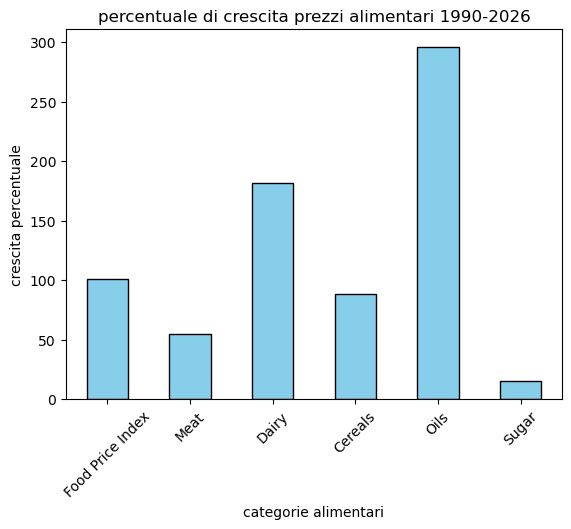

In [25]:
import matplotlib.pyplot as plt
categorie = ['Food Price Index', 'Meat', 'Dairy', 'Cereals', 'Oils', 'Sugar']
dati_grafico=crescita_perc[categorie]
dati_grafico.plot(kind='bar',color='skyblue',edgecolor='black')
plt.title('percentuale di crescita prezzi alimentari 1990-2026')
plt.xlabel('categorie alimentari')
plt.ylabel('crescita percentuale')
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

In [26]:
matrice=df[col].corr()
matrice

,Meat,Dairy,Cereals,Oils,Sugar
Meat,1.000000,0.813152,0.808837,0.799982,0.739490
Dairy,0.813152,1.000000,0.898318,0.871589,0.678922
Cereals,0.808837,0.898318,1.000000,0.899929,0.752166
Oils,0.799982,0.871589,0.899929,1.000000,0.709799
Sugar,0.739490,0.678922,0.752166,0.709799,1.000000


<Axes: >

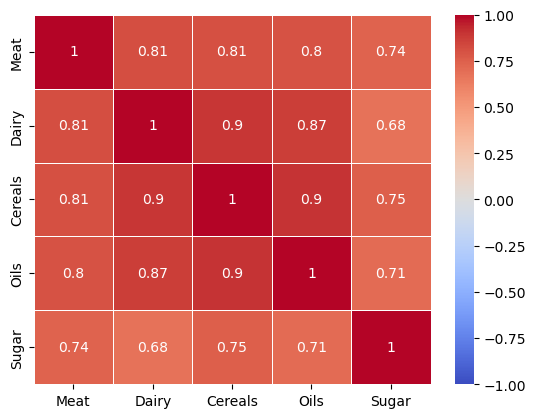

In [27]:
import seaborn as sns
sns.heatmap(matrice,annot=True,cmap='coolwarm',vmin=-1,vmax=1,linewidths=0.5)

In [28]:
df['oil_tomeat_ratio']=df['Oils']/df['Meat']

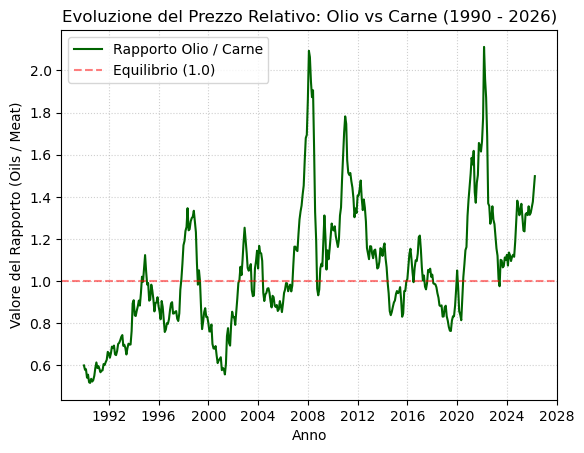

In [29]:
plt.plot(df['Date'],df['oil_tomeat_ratio'],color='darkgreen', label='Rapporto Olio / Carne')
plt.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Equilibrio (1.0)')
plt.xlabel('Anno')
plt.ylabel('Valore del Rapporto (Oils / Meat)')
plt.title('Evoluzione del Prezzo Relativo: Olio vs Carne (1990 - 2026)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

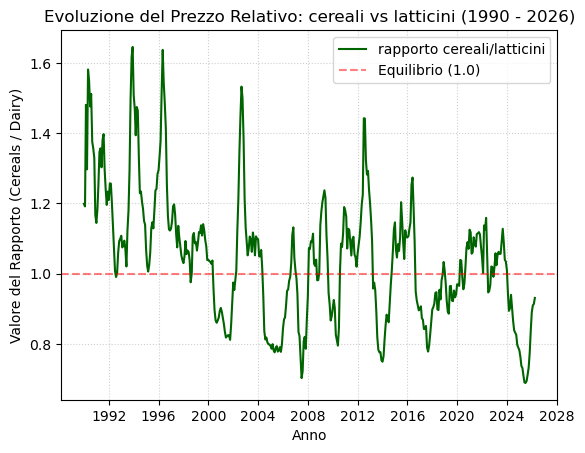

In [30]:
df['cereal_to_dairy_ratio']=df['Cereals']/df['Dairy']
plt.plot(df['Date'],df['cereal_to_dairy_ratio'],color='darkgreen',label='rapporto cereali/latticini')
plt.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Equilibrio (1.0)')
plt.xlabel('Anno')
plt.ylabel('Valore del Rapporto (Cereals / Dairy)')
plt.title('Evoluzione del Prezzo Relativo: cereali vs latticini (1990 - 2026)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

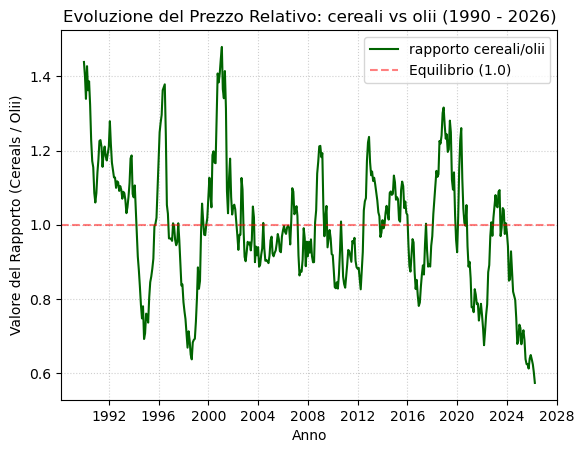

In [31]:
df['cereal_to_oils_ratio']=df['Cereals']/df['Oils']
plt.plot(df['Date'],df['cereal_to_oils_ratio'],color='darkgreen',label='rapporto cereali/olii')
plt.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Equilibrio (1.0)')
plt.xlabel('Anno')
plt.ylabel('Valore del Rapporto (Cereals / Olii)')
plt.title('Evoluzione del Prezzo Relativo: cereali vs olii (1990 - 2026)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

In [32]:
df['prezzo_mese_precedente']=df['Food Price Index'].shift(1)
df['variazione_mensile']=df['Food Price Index']-df['prezzo_mese_precedente']
df_ml=df.dropna()

In [33]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
X = df_ml[['prezzo_mese_precedente']]
y = df_ml['Food Price Index']

In [34]:
X_train, X_test = X.iloc[:-12], X.iloc[-12:]
y_train, y_test = y.iloc[:-12], y.iloc[-12:]
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [35]:
mae_lr=mean_absolute_error(y_test,lr_preds)
mae_lr

1.3764690126649743

In [36]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, rf_preds)
mae_rf

1.689061061372584

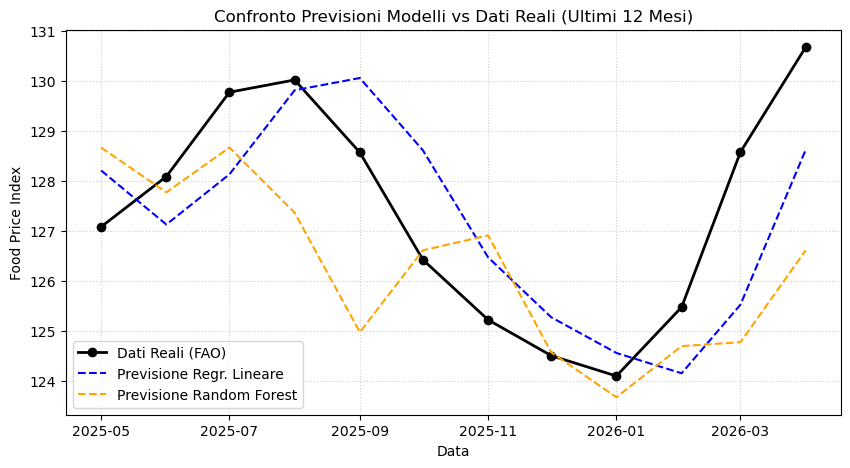

In [37]:
plt.figure(figsize=(10, 5))
date_test = df_ml['Date'].iloc[-12:] # Le date degli ultimi 12 mesi

plt.plot(date_test, y_test, label='Dati Reali (FAO)', color='black', marker='o', linewidth=2)
plt.plot(date_test, lr_preds, label='Previsione Regr. Lineare', linestyle='--', color='blue')
plt.plot(date_test, rf_preds, label='Previsione Random Forest', linestyle='--', color='orange')

plt.title('Confronto Previsioni Modelli vs Dati Reali (Ultimi 12 Mesi)')
plt.xlabel('Data')
plt.ylabel('Food Price Index')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [40]:
X_totale = df_ml[['prezzo_mese_precedente']]
y_totale = df_ml['Food Price Index']

modello_futuro = LinearRegression()
modello_futuro.fit(X_totale, y_totale)
ultimo_prezzo_noto = df_ml['Food Price Index'].iloc[-1]

previsioni_futuro = []
prezzo_corrente = ultimo_prezzo_noto
date_future = pd.date_range(start=df_ml['Date'].iloc[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

for mese in range(12):
    input_df = pd.DataFrame([[prezzo_corrente]], columns=['Prezzo_Mese_Precedente'])
    prossimo_prezzo = modello_futuro.predict(input_modello)[0]
    previsioni_futuro.append(prossimo_prezzo)
    prezzo_corrente = prossimo_prezzo
df_previsioni_2027 = pd.DataFrame({
    'Mese': date_future.strftime('%B %Y'),
    'Prezzo Predetto (Food Price Index)': np.round(previsioni_futuro, 2)
})

print("=== LE TUE PREVISIONI PER IL 2026/2027 ===")
print(df_previsioni_2027.to_string(index=False))    

=== LE TUE PREVISIONI PER IL 2026/2027 ===
          Mese  Prezzo Predetto (Food Price Index)
      May 2026                              131.26
     June 2026                              131.26
     July 2026                              131.26
   August 2026                              131.26
September 2026                              131.26
  October 2026                              131.26
 November 2026                              131.26
 December 2026                              131.26
  January 2027                              131.26
 February 2027                              131.26
    March 2027                              131.26
    April 2027                              131.26


/home/elena/miniconda3/envs/data2/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/elena/miniconda3/envs/data2/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/elena/miniconda3/envs/data2/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/elena/miniconda3/envs/data2/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/elena/miniconda3/envs/data2/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature 

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# Assicuriamoci che la colonna Date sia in formato datetime
df['Date'] = pd.to_datetime(df['Date'])

# --- 1. CREAZIONE DELLE FEATURE AVANZATE ---
df_features = df.copy()

# Aggiungiamo i Lag storici (i ricordi del modello)
df_features['Lag_1'] = df_features['Food Price Index'].shift(1)
df_features['Lag_2'] = df_features['Food Price Index'].shift(2)
df_features['Lag_12'] = df_features['Food Price Index'].shift(12) # Lo stesso mese dell'anno scorso

# Aggiungiamo la Stagionalità (estraiamo il mese come numero)
df_features['Mese_Num'] = df_features['Date'].dt.month

# Puliamo i valori nulli creati dagli shift (le prime 12 righe del 1990 non avranno il Lag_12)
df_ml_avanzato = df_features.dropna().reset_index(drop=True)

# --- 2. ADDESTRAMENTO ---
# Le nostre Feature ora sono 4; il Target rimane l'indice attuale
features_col = ['Lag_1', 'Lag_2', 'Lag_12', 'Mese_Num']
X_totale = df_ml_avanzato[features_col]
y_totale = df_ml_avanzato['Food Price Index']

# Usiamo il Random Forest per gestire la complessità delle stagioni
modello_avanzato = RandomForestRegressor(n_estimators=100, random_state=42)
modello_avanzato.fit(X_totale, y_totale)

# --- 3. PREVISIONE RICORSIVA SUL FUTURO (12 MESI) ---
# Creiamo una copia del dataset per memorizzare i dati futuri man mano che li calcoliamo
df_proiezione = df_ml_avanzato.copy()

# Generiamo le date future da Maggio 2026 ad Aprile 2027
date_future = pd.date_range(start=df_proiezione['Date'].iloc[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

for nuova_data in date_future:
    # 1. Recuperiamo l'ultima riga disponibile nel nostro dataset in crescita
    ultima_riga = df_proiezione.iloc[-1]
    
    # 2. Calcoliamo i lag per il nuovo mese che stiamo per prevedere
    # Nota: il Lag_1 di "domani" è il prezzo di "oggi", il Lag_2 di domani è il prezzo di ieri, ecc.
    nuovo_lag_1 = df_proiezione['Food Price Index'].iloc[-1]
    nuovo_lag_2 = df_proiezione['Food Price Index'].iloc[-2]
    nuovo_lag_12 = df_proiezione['Food Price Index'].iloc[-12] # Il prezzo di 12 mesi prima rispetto al mese futuro
    nuovo_mese_num = nuova_data.month
    
    # 3. Prepariamo i dati per il modello rispettando i nomi delle colonne
    input_dati = pd.DataFrame([[nuovo_lag_1, nuovo_lag_2, nuovo_lag_12, nuovo_mese_num]], columns=features_col)
    
    # 4. Facciamo la previsione
    predizione = modello_avanzato.predict(input_dati)[0]
    
    # 5. Aggiungiamo la nuova riga con la previsione al dataset, così i cicli successivi la useranno come passato!
    nuova_riga = {
        'Date': nuova_data,
        'Food Price Index': predizione,
        'Lag_1': nuovo_lag_1,
        'Lag_2': nuovo_lag_2,
        'Lag_12': nuovo_lag_12,
        'Mese_Num': nuovo_mese_num
    }
    df_proiezione = pd.concat([df_proiezione, pd.DataFrame([nuova_riga])], ignore_index=True)

# --- 4. MOSTRA I RISULTATI ---
estratto_2027 = df_proiezione.tail(12)[['Date', 'Food Price Index']]
estratto_2027['Date'] = estratto_2027['Date'].dt.strftime('%B %Y')
print("=== PREVISIONI DINAMICHE 2026/2027 ===")
print(estratto_2027.to_string(index=False))

=== PREVISIONI DINAMICHE 2026/2027 ===
          Date  Food Price Index
      May 2026        129.497948
     June 2026        128.960458
     July 2026        128.947608
   August 2026        128.707700
September 2026        127.863425
  October 2026        126.989660
 November 2026        126.360308
 December 2026        125.525630
  January 2027        125.961896
 February 2027        126.162490
    March 2027        125.132985
    April 2027        124.277672


In [43]:
from sklearn.metrics import mean_absolute_error

# 1. Dividiamo i dati in Train (tutto il passato) e Test (gli ultimi 12 mesi REALI che conosciamo)
# Lasciamo l'ultimo anno come banco di prova
X_train, X_test = X_totale.iloc[:-12], X_totale.iloc[-12:]
y_train, y_test = y_totale.iloc[:-12], y_totale.iloc[-12:]

# 2. Addestriamo il modello solo sulla parte Train
modello_valutazione = RandomForestRegressor(n_estimators=100, random_state=42)
modello_valutazione.fit(X_train, y_train)

# 3. Facciamo finta di non conoscere gli ultimi 12 mesi e lasciamo che il modello li predica
# Usiamo i dati reali delle feature del Test Set per vedere cosa avrebbe risposto il modello
predizioni_test = modello_valutazione.predict(X_test)

# 4. ORA POSSIAMO CALCOLARE IL MAE CORRETTO! 
# Confrontiamo i 12 mesi reali (y_test) con i 12 mesi indovinati (predizioni_test)
mae_avanzato = mean_absolute_error(y_test, predizioni_test)

print(f"Il vero MAE del modello evoluto è: {mae_avanzato:.2f} punti di indice")

Il vero MAE del modello evoluto è: 1.77 punti di indice


In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 1. Utilizziamo lo stesso dataset df_ml_avanzato creato nel passaggio precedente
features_col = ['Lag_1', 'Lag_2', 'Lag_12', 'Mese_Num']
X_totale = df_ml_avanzato[features_col]
y_totale = df_ml_avanzato['Food Price Index']

# 2. Dividiamo rigidamente in Train e Test (ultimi 12 mesi noti)
X_train, X_test = X_totale.iloc[:-12], X_totale.iloc[-12:]
y_train, y_test = y_totale.iloc[:-12], y_totale.iloc[-12:]

# 3. Addestriamo la Regressione Lineare
lr_avanzato = LinearRegression()
lr_avanzato.fit(X_train, y_train)

# 4. Generiamo le previsioni per il Test Set
predizioni_lr_avanzate = lr_avanzato.predict(X_test)

# 5. Calcoliamo il nuovo MAE
mae_lr_avanzato = mean_absolute_error(y_test, predizioni_lr_avanzate)

print(f"MAE della Regressione Lineare Avanzata (4 feature): {mae_lr_avanzato:.2f} punti")

MAE della Regressione Lineare Avanzata (4 feature): 1.04 punti



=== LE TUE PREVISIONI EVOLUTE PER IL 2026/2027 ===
          Mese  Prezzo Predetto
      May 2026           131.61
     June 2026           131.93
     July 2026           131.91
   August 2026           131.68
September 2026           131.31
  October 2026           130.83
 November 2026           130.26
 December 2026           129.61
  January 2027           129.39
 February 2027           129.35
    March 2027           129.33
    April 2027           129.28


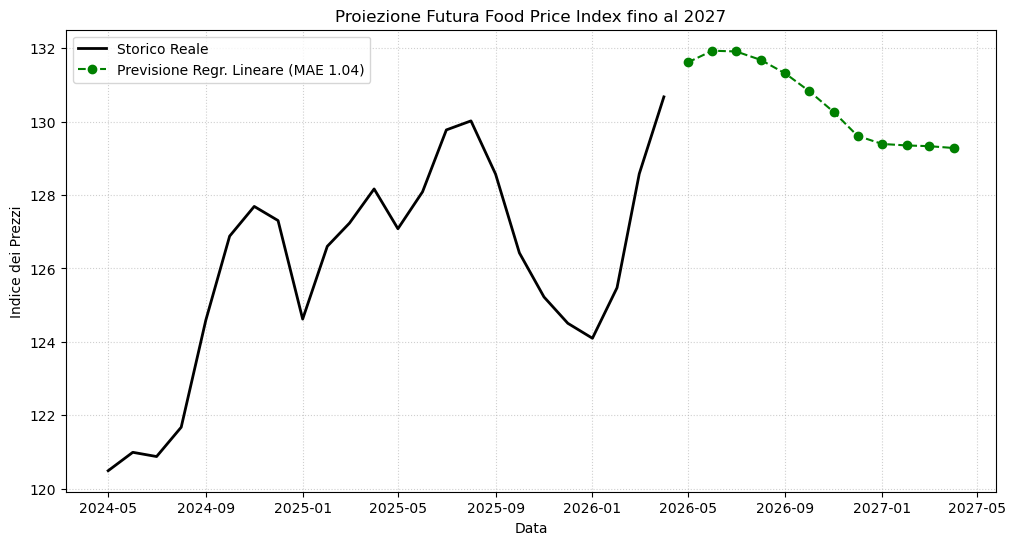

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- 1. ADDESTRAMENTO COMPLETO ---
# Usiamo tutte le feature avanzate e l'intero dataset a disposizione
features_col = ['Lag_1', 'Lag_2', 'Lag_12', 'Mese_Num']
X_totale = df_ml_avanzato[features_col]
y_totale = df_ml_avanzato['Food Price Index']

modello_finale = LinearRegression()
modello_finale.fit(X_totale, y_totale)

# --- 2. PROIEZIONE RICORSIVA SUL FUTURO (12 MESI) ---
# Creiamo un nuovo DataFrame che estenderemo mese dopo mese con le previsioni
df_futuro = df_ml_avanzato.copy()

# Generiamo i prossimi 12 mesi da Maggio 2026 ad Aprile 2027
date_future = pd.date_range(start=df_futuro['Date'].iloc[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

for nuova_data in date_future:
    # Recuperiamo i lag corretti attingendo dagli ultimi mesi del dataset in crescita
    nuovo_lag_1 = df_futuro['Food Price Index'].iloc[-1]
    nuovo_lag_2 = df_futuro['Food Price Index'].iloc[-2]
    nuovo_lag_12 = df_futuro['Food Price Index'].iloc[-12] # Stesso mese dell'anno precedente
    nuovo_mese_num = nuova_data.month
    
    # Costruiamo il DataFrame di input con i nomi delle colonne per evitare i Warning
    input_dati = pd.DataFrame([[nuovo_lag_1, nuovo_lag_2, nuovo_lag_12, nuovo_mese_num]], columns=features_col)
    
    # Il modello predice il valore del mese futuro
    predizione = modello_finale.predict(input_dati)[0]
    
    # Inseriamo la riga nel DataFrame per renderla disponibile ai calcoli dei mesi successivi
    nuova_riga = {
        'Date': nuova_data,
        'Food Price Index': predizione,
        'Lag_1': nuovo_lag_1,
        'Lag_2': nuovo_lag_2,
        'Lag_12': nuovo_lag_12,
        'Mese_Num': nuovo_mese_num
    }
    df_futuro = pd.concat([df_futuro, pd.DataFrame([nuova_riga])], ignore_index=True)

# --- 3. CREAZIONE DELLA TABELLA FINALE ---
estratto_futuro = df_futuro.tail(12)[['Date', 'Food Price Index']].copy()
estratto_futuro['Mese'] = estratto_futuro['Date'].dt.strftime('%B %Y')
estratto_futuro['Prezzo Predetto'] = np.round(estratto_futuro['Food Price Index'], 2)

print("\n=== LE TUE PREVISIONI EVOLUTE PER IL 2026/2027 ===")
print(estratto_futuro[['Mese', 'Prezzo Predetto']].to_string(index=False))

# --- 4. GRAFICO DEL TREND FUTURO ---
plt.figure(figsize=(12, 6))
# Mostriamo l'ultimo anno storico per avere contesto visuale
dati_recenti = df_ml_avanzato.tail(24)
plt.plot(dati_recenti['Date'], dati_recenti['Food Price Index'], label='Storico Reale', color='black', linewidth=2)

# Mostriamo la proiezione futura
plt.plot(estratto_futuro['Date'], estratto_futuro['Prezzo Predetto'], label='Previsione Regr. Lineare (MAE 1.04)', color='green', linestyle='--', marker='o')

plt.title('Proiezione Futura Food Price Index fino al 2027')
plt.xlabel('Data')
plt.ylabel('Indice dei Prezzi')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()